# Auto-differentiation and Program Transformation
Knowing a model $\mathbf{x}_{t+1} = f(\mathbf{x}_t, \mathbf{u}_t)$ can help to answer questions like "what $\mathbf{u}_t$ should be taken when the goal is to reach $\mathbf{x}_{t+1}$ and $\mathbf{u}$ must be within a range of $[-5, 5]$". The question can be formulated as solving $\arg\min\limits_{ \|\mathbf{u}_t\| \leq 5} \| \mathbf{x}_{t+1} - f(\mathbf{x}_t, \mathbf{u}_t) \|$, typically solved by gradient-based optimization which needs to evaluate the derivative $\partial f /\partial \mathbf{u}_{t}$. When the computation of $f(\mathbf{x}_t, \mathbf{u}_t)$ is implemented as a lengthy program, like our articulated dynamics algorithms, it would be very convenient to have a method to _differentiate_ this program process. Such a method is obviously not only useful for this specific application but also benefits general scientific computing. 


The simplest way to evaluate the derivative of a function $f(x)$ at $x$ is following the definition:
$$
\frac{\partial f}{\partial x}(x) = \lim_{h \rightarrow 0} \frac{f(x+h) - f(x)}{h} \approx \frac{f(x+\delta x) - f(x)}{\delta x}
$$
By choosing a small $\delta x$, the evaluation will yield a result close to the real value. This is called _finite difference_ approximation and can be applied with other ways of perturbing $x$ with $\delta x$, e.g. $\frac{f(x) - f(x-\delta x)}{\delta x}$ or $\frac{f(x+\delta x) - f(x-\delta x)}{2\delta x}$. The benefit of finite difference is its straightforward implementation: only the original function evaluation is needed. Existing functions can be wrapped to implement their differentials without knowing the implementation details. However, querying the differential once incurrs multiple function queries. This could be extremely expensive as in the case of neural networks, which can easily have millions of parameters. Meanwhile, care must be taken to choose a proper $\delta x$ for the balance of accuracy and numerical stability. 

That said, finite difference can still be very useful when the size of input variable is moderate and fast parallelized function evaluation is available. It is also useful for checking the correctness of other differentiation techniques. The generality makes it the default option of calculating gradients in many optimization software. As an example, consider optimizing the Rosenbrock function with $n$ input variables:
$$
f(x_1, x_2, ..., x_n) = \sum\limits_{i=1}^{n-1} a(x_{i+1} -x_i^2)^2 + (b-x_i)^2
$$

Finding the minimal of the Rosenbrock function is the "hello world" example for solvers to test various optimization algorithms. Here we stick to a 2d example for the ease of visualization:



In [2]:
def rosenbrock(x, y):
    a = 1
    b = 0
    return  a*(y-x**2)**2 + (b-x)**2



whose loss surface looks like:

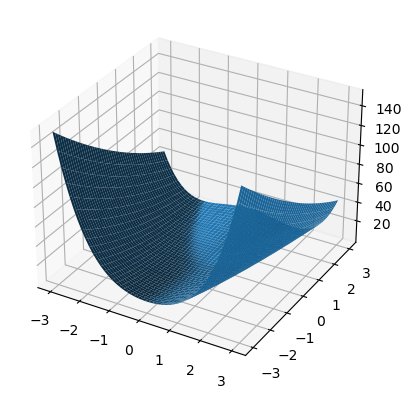

In [3]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-3, 3, 50)
y = np.linspace(-3, 3, 50)
X, Y = np.meshgrid(x, y)

Z = rosenbrock(X, Y)

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection='3d')

surf = ax.plot_surface(X, Y, Z)


Calling the `minimize` fucntion in the [scipy.optimize](https://docs.scipy.org/doc/scipy/reference/optimize.html#module-scipy.optimize) package can help to find the minimal location on this loss landscape. Note we only provide the optimizer with the loss function while leave the gradient evaluation `jac` to a 2-point finite difference approximation.

In [4]:
import numpy as np
import scipy.optimize

rosenbrock_loss = lambda x: rosenbrock(x[0], x[1])

np.random.seed(0)
init_guess = np.random.randn(2)
result = scipy.optimize.minimize(rosenbrock_loss, init_guess, method='BFGS', jac='2-point')

print(result)



  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.6481970455515987e-15
        x: [-1.678e-09  4.056e-08]
      nit: 10
      jac: [-1.826e-08  9.603e-08]
 hess_inv: [[ 5.003e-01 -9.094e-04]
            [-9.094e-04  5.031e-01]]
     nfev: 33
     njev: 11


It is easy to verify that the returned result is fairly close to `[0, 0]` which is obviously the minimal of the Rosenbrock function with `a=1` and `b=0`. Note that it takes `nit:`{eval}`result.nit` iterations to reach the solution. The loss function is called `nfev:`{eval}`result.nfev` times for `njev:`{eval}`result.njev` gradient function evaluation. 

:::{tip} Exercise
Why the ratio between loss function and gradient function evaluation is like this? Note that 2-point finite difference calculates $\frac{f(x) - f(x-\delta x)}{\delta x}$. Try to run the same process with `jac='3-point'` and see how the numbers change. What would happen if we have many input variables?
:::



## Auto-differentiation - Breaking Program to Elementary Operations and Computation Graph
To obtain an exact evaluation of differentials, one may analytically differentiate the output with respect to the input, e.g. by applying the chain rule. This is of course error-prone by hand when the computation is complex. Symbolic differentiation in software like Maple or Mathematica can convert the mathematical expression to its differential. The program function to differentiate, however, might not always be easy to write as a math expression like the Rosenbrock function, for example when the program contains control flow statements.

Automatic differentiation (often referred as auto-diff or auto-grad) addresses this by transforming a program calculating numerical values to another program that computes both values and derivatives. Auto-diff shares some similarities with symbolic differentiation. The chain rule principle is also adopted but applied alongside the program execution. This makes it suitable for complex program code like finite difference while also provide numerical accuracy up to the machine precision.

Recall that a program can be abstracted as a flowchart in which variables are computed with data flown over their dependencies. Indeed, running functions like the Rosenbrock can be broken down into many elementary operations. These operations create connections linking input variables and the output, resulting a __computation graph__ with nodes as variables and edges as operations:
```{figure} ../images/compgraph.png
---
height: 300px
name: computational_graph
---
The logic of computing the Rosenbrock function breaks down into elementary operations with intermediate variables connected as a directed graph.
```
In this graph, `a=1` and `b=0` are denoted as constants and arithematic operations are used here and there. Some operation is unitary like `neg(x)=-x` while some operations receive multiple input as dependencies, e.g. `add(x, y) = x + y`. Nevertheless, these operations are basic and easy to differentiate by hand. It would hence be simple to override these operations with additional derivative evaluation for the input variables. For the instance of `z = mul(x, y) = x*y`, the override `mul(x, y)` will also compute and store `dzdx = y` and `dzdy = x`. One can imagine that the derivative between any output and input can be obtained by chaining all these intermediate derivative evaluation, e.g. with `z4 = mul(1, add(y, neg(pow(x))))`. This provides a way of mechanically transforming a program and computing its derivatives without finite difference approximation. 

One may wonder about the expense to pay for the additional auto-diff feature. To investigate this, let's consider a process $f: \mathbb{R}^n \rightarrow \mathbb{R}^m$ as a composed function $\mathbf{y} = f_p \cdot f_{p-1} ... f_1(\mathbf{x})$, generalizing the computation branch of `z4`. The differentiation can be written as

$$
\label{eq-chainrule}
\begin{aligned}
\frac{\partial \mathbf{y}}{\partial \mathbf{x}} = \mathbf{J}_p \mathbf{J}_{p-1} ... \mathbf{J}_{1}
\end{aligned}
$$

where $\mathbf{J}_i$ is the Jacobian composed by the differentials of elementary operations. Computationally we need to evaluate the derivatives of elementary operations anyway as the analytical evaluation. The tricky part comes from storing the intermediate derivatives. The original program may need memory fitting the largest size of $\mathbf{z}_i = f_i(\mathbf{z}_{i-1})$ to store intermediate results. The transformed program concerns Jacobians, whose memory costs may be at the scale of the product of input and output lengths. A naive implementation can thus be memory intensive when the intermediate steps need to compute variables of a large size, e.g. neural networks with large layer input and output. 


## Auto-differentiation - Forward Mode
In many processes, the derivatives are not the end results but used in other computational steps. For instance, it is common to evaluate the product of a Jacobian matrix and a vector $\mathbf{v}$, turning [](#eq-chainrule) to:

$$
\label{eq-adforward}
\frac{\partial \mathbf{y}}{\partial \mathbf{x}} \cdot \mathbf{v} = \mathbf{J}_p \mathbf{J}_{p-1} ... \mathbf{J}_{1} \cdot \mathbf{v}
$$

In contrast to first computing the Jacobian as a whole, the same result can be obtained by evaluating the equation from __right to left__, i.e. computing $\mathbf{v}_1 = \mathbf{J}_1\cdot\mathbf{v}$ and then $\mathbf{v}_2 = \mathbf{J}_2\cdot\mathbf{v}_1$... Every intermediate step now has to deal with a vector and a Jacobian matrix instead of two matrices. This will significantly reduce the memory and computational cost comparing to the naive implementation.

Let's have a look at the meaning of these intermediate variables for the program step of $\mathbf{z}_i = f_i(\mathbf{z}_{i-1})$, for which $\mathbf{v}_i = \mathbf{J}_i \cdot \mathbf{v}_{i-1} = \frac{\partial \mathbf{z}_i}{\partial \mathbf{z}_{i-1}} \cdot \mathbf{v}_{i-1}$. If we choose the initial $\mathbf{v}$ as the time-derivative of initial input $\mathbf{x}$, i.e. $\mathbf{v} = \dot{\mathbf{x}} = [\frac{dx_1}{dt}, \frac{dx_2}{dt}, ..., \frac{dx_n}{dt}]^\top$, the intermediate variable of the transformed program is the time-derivative of intermdiate variable of the original program, i.e. $\mathbf{v}_i = \dot{\mathbf{z}}_i$. This implies that the additional derivatives will take the same amount of memory as the corresponding variables and more importantly, the derivatives can be computed alongside the execution of the original program. This is called __forward mode__ automatic differentiation since the differentials are calculated in the forward direction of running the program, i.e. the traverse of the computation graph. Taking the Rosenbrock function as an example, we can extend all variable nodes with their time-derivative and compute them when operation functions are called, e.g. $z_1 = x^2$ and $\dot{z}_1 = 2 \times x \times \dot{x}$. For python code, we can simply implement something like:


In [5]:
class Number:
    def __init__(self, val) -> None:
        self.val = val
        self.dvdx = 0       #grad for forward mode
    
    def __add__(self, obj):
        #auto conversion when obj is float or int
        obj = obj if isinstance(obj, Number) else Number(val=obj)
        ret = Number(val=self.val + obj.val)
        ret.dvdx = self.dvdx + obj.dvdx
        return ret
    
    def __mul__(self, obj):
        #auto conversion when obj is float or int
        obj = obj if isinstance(obj, Number) else Number(val=obj)
        ret = Number(val=self.val*obj.val)
        #for forward mode
        # c = a * b
        # dcdx = dadx * b + a * dbdx
        ret.dvdx = self.dvdx * obj.val + self.val * obj.dvdx
        return ret
    
    def __pow__(self, obj):
        # derivative dcda for a ** b = c requires a > 0
        # lets only accept constant obj
        assert isinstance(obj, (int, float))
        ret = Number(val=self.val ** obj)
        #for forward mode
        # c = a ** b
        # dcdx = b * a ** (b-1) * dadx
        ret.dvdx = (obj * self.val**(obj-1)) * self.dvdx
        return ret

    #other operations based on basic add and mul
    def __neg__(self):
        return self * Number(val=-1)
    
    def __radd__(self, obj):
        return self + obj
    
    def __sub__(self, obj):
        return self + (-obj)
    
    def __rsub__(self, obj): 
        return obj + (-self)

    def __rmul__(self, obj): 
        return self * obj

    

where a `Number` object represents a node in the graph and we name the associated derivative as `dvdx`. `Number` can then be used for writing regular python code:

In [6]:
x = Number(1.57)
x.dvdx = 1.
y = Number(-0.88)

r = rosenbrock(x, y)
r_val = rosenbrock(1.57, -0.88)
print(r.val, r_val)

13.65325601 13.65325601


Setting `x.dvdx` to `1` does not impact the computation of the Rosenbrock function but its derivative to the first input `x`. To see this, consider $\mathbf{v} = [\frac{dx_1}{dx_1}, \frac{dx_2}{dx_1}, ..., \frac{dx_n}{dx_1}]^\top = [1, 0, ..., 0]^\top$, [](#eq-adforward) is essentially computing the first column of the Jacobian. In general, we can set `1` to `dvdx` of the i-th input while keeping other `dvdx` to `0` to compute the i-th column of Jacobian. We can verify the result with finite difference:

In [7]:
drdx = scipy.optimize.approx_fprime(1.57, lambda x: rosenbrock(x, -0.88))
print(r.dvdx, drdx)

24.145972 [24.14597225]


The advantage of forward mode differentiation lies in its simplicity for understanding and implementation. There is little to change about how the original program is executed. It is also memory efficient as we only have to maintain the graph front as the traverse goes. Forward mode differentiation is effective when the target is to compute time-derivative or Jacobian columns (or $m \times 1$ Jacobian) as it takes only one run for functions with multivariate output. 

## Auto-differentiation - Reverse Mode
Using forward mode differentiation to evaluate a gradient ($1 \times n$ Jacobian) will take $n$ times of traverse of the computation graph, each time with the i-th input's differential `dvdx` set to `1`. This is on the same order in finite diffence. Gradient-based optimization needs more efficient evaluation to make it independent of the input dimension. 

In numerical optimization, the program output, e.g. $\mathbf{y}$ of $\mathbf{y} = f_p \cdot f_{p-1} ... f_1(\mathbf{x})$, is assessed with a loss function, e.g. $l(\mathbf{y})$. This yields an extra composition to the program, now as $l: \mathbb{R}^m \rightarrow \mathbb{R}$. Taking the derivative will unravel the computation as a form of Vector-Jacobian-Product:

$$
\label{eq-adreverse}
\begin{aligned}
\nabla l(\mathbf{x}) = \mathbf{v} \cdot \frac{\partial \mathbf{y}}{\partial \mathbf{x}} = \mathbf{v} \cdot \mathbf{J}_p \mathbf{J}_{p-1} ... \mathbf{J}_{1}
\end{aligned}
$$

where $\mathbf{v} = [\frac{\partial l}{\partial y_1}, \frac{\partial l}{\partial y_2}, ..., \frac{\partial l}{\partial y_m}]$. Similar to the argument in forward model differentiation, it would be more efficient to evaluate the equation from __left to right__ this time. This implies that our transformed program needs to reversely traverse the computation graph, with each $\mathbf{v}_i$ now carrying $\frac{\partial l}{\partial \mathbf{z}_i}$. Again using the Rosenbrock example, the graph computation is as what follows:

```{figure} ../images/compgraph_rev.png
---
height: 300px
name: reverse_computational_graph
---
The logic of computing the gradient of Rosenbrock function by reversing the traverse of graph.
```

Specifically, the propagation of $\frac{\partial l}{\partial \mathbf{z}_i}$ depends on the operation used to yield $\mathbf{z}_{i+1}$, e.g. $\frac{\partial l}{\partial z_6} = \frac{\partial l}{\partial z_7} \frac{\partial z_7}{\partial z_6} = \frac{\partial l}{\partial z_7} \times 2z_6$ because $z_7 = z_6^2$. For code implementation, we will need to store all nodes values and register the dependencies to trace back in the backward traverse. The differential of the predecessor node in the original graph can only be evaluated after its successor nodes. To achieve this, we may reverse the [topological order](https://en.wikipedia.org/wiki/Topological_sorting) of the computation graph which requires the same order of complexity of traversing the graph. An example of python implementation could be: 

In [8]:
import math

class Number:
    def __init__(self, val) -> None:
        self.val = val
        self.dldv = 0       #grad for reverse mode
        self.prev = []
        self._backward = lambda: None   #do nothing by default
    
    def __add__(self, obj):
        #auto conversion when obj is float or int
        obj = obj if isinstance(obj, Number) else Number(val=obj)
        ret = Number(val=self.val + obj.val)
        ret.prev = [self, obj]
        #for reverse mode
        def _backward():
            # a + b = c
            # dlda = dldc * dcda = dldc
            self.dldv += ret.dldv
            obj.dldv += ret.dldv
        ret._backward = _backward
        return ret
    
    def __mul__(self, obj):
        #auto conversion when obj is float or int
        obj = obj if isinstance(obj, Number) else Number(val=obj)
        ret = Number(val=self.val*obj.val)
        ret.prev = [self, obj]
        #for reverse mode
        def _backward():
            #a * b = c
            #dlda = dldc * dcda = dldc * b
            self.dldv += ret.dldv * obj.val
            obj.dldv += ret.dldv * self.val
        ret._backward = _backward
        return ret
    
    def __pow__(self, obj):
        # derivative dcda for a ** b = c requires a > 0
        # lets only accept constant obj
        assert isinstance(obj, (int, float))
        ret = Number(val=self.val ** obj)
        ret.prev = [self]
        #for reverse mode
        def _backward():
            #a ** b = c
            #dlda = dldc * dcda = dldc * (b*a**(b-1))
            #dldb = dldc * dcdb = dldc * (a**b * log(a))
            self.dldv += ret.dldv * (obj * self.val**(obj-1))
        ret._backward = _backward
        return ret
    
    def exp(self):
        ret = Number(val=math.e ** self.val)
        ret.prev = [self]
        #for reverse mode
        def _backward():
            #a ** b = c
            #dlda = dldc * dcda = dldc * (b*a**(b-1))
            #dldb = dldc * dcdb = dldc * (a**b * log(a))
            self.dldv += ret.dldv * math.e ** self.val        
        ret._backward = _backward
        return ret

    def __neg__(self):
        return self * Number(val=-1)
    
    def __radd__(self, obj):
        return self + obj
    
    def __sub__(self, obj):
        return self + (-obj)
    
    def __rsub__(self, obj): 
        return obj + (-self)

    def __rmul__(self, obj): 
        return self * obj

    def __truediv__(self, obj): 
        return self * obj**Number(val=-1)
    
    def __rtruediv__(self, obj): 
        return obj * self**-1
    
    def _build_topo_ordered_set(self, topo_list=[], visited=set()):
        #traverse all number nodes that this number depends on by building a list subject to topological order
        #note there might be some nodes used multiple times, mark them to avoid multiple backward call
        if self not in visited:
            visited.add(self)
            for num in self.prev:
                num._build_topo_ordered_set(topo_list, visited=visited)
            topo_list.append(self)
        return 
        
    def backward(self):
        topo_ordered_list = []
        self._build_topo_ordered_set(topo_ordered_list, set())
        self.dldv = 1.  # l = v here
        for num in reversed(topo_ordered_list):
            num._backward()
        return
    
    def zero_grad(self):
        #reset dldv for all dependent nodes
        topo_ordered_list = []
        self._build_topo_ordered_set(topo_ordered_list, set())
        for num in reversed(topo_ordered_list):
            num.dldv = 0
        return
    

And this time only one backward sweep is needed to evaluate the Rosenbrock gradient:


In [9]:
x = Number(1.57)
y = Number(-0.88)

r = rosenbrock(x, y)
r.dldv = 1.
r.backward()

r_grad = scipy.optimize.approx_fprime([1.57, -0.88], rosenbrock_loss)
print([x.dldv, y.dldv], r_grad)

[24.145972, -6.6898] [24.14597225 -6.68980002]


Setting `r.dldv = 1` is obvious becasue the output is $l$ itself in this case. In general, when the output is multivariate, we can see a similar way of setting one-hot $\mathbf{v}$ in [](eq-adreverse), e.g. with $\mathbf{v} = [1, 0, ..., 0]$ to get the first row of Jacobian. 

The differentiation is not exclusive to basic arithmetic operations. The above code also implements `exp` and its backward step. We can use this `Number` system to build a small neural network with [sigmoid](https://en.wikipedia.org/wiki/Sigmoid_function) activation. The auto-differentiation is used in training a linear classifier for two groups of Gaussian distributed data:

In [10]:
import numpy as np
import random

np.random.seed(0)
random.seed(0)
#test with linear classification
#generate 2D data from two clusters
N = 10
pnts1 = np.random.multivariate_normal(mean=[1.5, 1.5], cov=[[0.5, -0.2], [-0.2, 0.5]], size=(N,))
pnts2 = np.random.multivariate_normal(mean=[0.5, 0.5], cov=[[0.3, -0.1], [-0.1, 0.3]], size=(N,))

data = [(pnt, 0) for pnt in pnts1] + [(pnt, 1) for pnt in pnts2]
random.shuffle(data)

x1_data = [Number(val=d[0][0]) for d in data]
x2_data = [Number(val=d[0][1]) for d in data]
y_data = [Number(val=d[1]) for d in data]

The network is simply $y = \text{sigmoid}(w_1x_1+w_2x_2+b)$. And the auto-differentiation can be leveraged for gradient descent in the manner similar to PyTorch:

In [11]:
w1 = Number(val=random.gauss(0.0, 1.0))
w2 = Number(val=random.gauss(0.0, 1.0))
b = Number(val=0)

def loss(w1, w2, b):
    tol_loss = Number(val=0.)
    for x1, x2, y in zip(x1_data, x2_data, y_data):
        y_hat = 1./((-(w1 * x1 + w2 * x2 + b)).exp() + 1)
        tol_loss = tol_loss + (y - y_hat) ** 2
    return tol_loss

n_itr = 50
lr = 1e-1
for i in range(n_itr):
    l = loss(w1, w2, b)
    l.zero_grad()
    l.backward()
    #apply learning rate to w and b
    w1.val = w1.val - lr * w1.dldv
    w2.val = w2.val - lr * w2.dldv
    b.val = b.val - lr * b.dldv
    if (i+1) % 10 == 0:
        print("Iteration {0}: Loss - {1}".format(i+1, l.val))

Iteration 10: Loss - 3.239878003563168
Iteration 20: Loss - 1.862441517870548
Iteration 30: Loss - 1.4571144472304598
Iteration 40: Loss - 1.2524646099829209
Iteration 50: Loss - 1.124522269647211


The gradient successfully updates the parameters to reduce the training loss. Let's visualize the decision boundary to see how the two groups are separated.

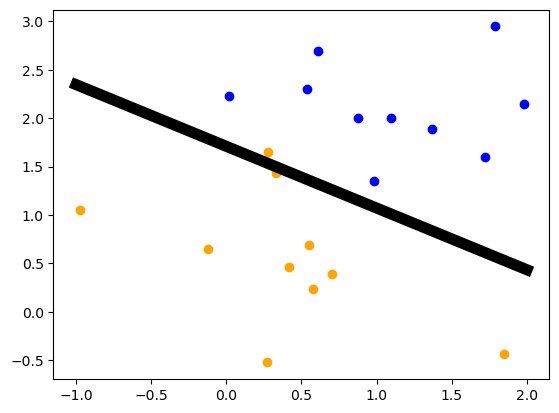

In [12]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(x=pnts1[:, 0], y=pnts1[:, 1], c='blue')
ax.scatter(x=pnts2[:, 0], y=pnts2[:, 1], c='orange')

x1 = np.linspace(-1, 2, 50)
x2 = (-b.val - w1.val * x1) / w2.val
ax.plot(x1, x2, '-k', linewidth=8, )

plt.show()

Reverse mode differentiation has the clear benefit of evaluating gradient ($1 \times n$ Jacobian) in one backward traverse. However, it needs to store intermediate variables before backward starts. This can incurr more memory cost when the computation graph is deep. 

## Practical Consideration
There are numerous software libraries that implement automatic differentiation to support scientific computing, such as PyTorch, [JAX](https://jax.readthedocs.io/en/latest/) and [Enzyme](https://enzyme.mit.edu) if your code can be compiled to LLVM IR. These libraries support evaluating Jacobians through both forward and reverse modes. For general $m \times n$ Jacobian, it is not hard to see that the forward mode is preferred when the Jacobian is "taller" ($m >> n$) and the reverse mode is more suitable for "wider" Jacobians ($m << n$).

One can also evaluate derivatives of higher-order by transforming the transformed program. This is nonetheless creating larger computation graphs. Differentiating such complex processes at an acceptable cost requires care in balancing the time and memory consumption. For instance, one may mix the forward and the reverse modes in evaluating the entire program to cater to the size of variables in different subprocesses. 

Conditional statements like `if` might need re-writing to an equivalent form when the conditions involve variables to differentiate. Refer to relevant document when this is what the code would like to do. Strictly speaking, conditional statements might create non-differentiability at the point where the condition flips. For instance, [ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html) has an abrupt change of function value at `0`. We can still happily train networks based on ReLU units because the function as a whole is still piece-wise differentiable (the measure of non-differentiable domain is zero) and a [subderivative](https://en.wikipedia.org/wiki/Subderivative) can be defined in this case. What derivative value to return at this point is up to a design choice. In PyTorch, the left-hand derivative `0` is returned.

We conclude this module by revisiting the Rosenbrock example with JAX. JAX provides a front-end almost identical to `numpy` so one can simply reuse the implementation and plug the gradient to `scipy.optimize.minimize`:

In [16]:
import jax

rosen_grad = jax.grad(rosenbrock_loss)

x0 = jax.numpy.array(init_guess)
result = scipy.optimize.minimize(rosenbrock_loss, x0, method='BFGS', jac=rosen_grad)
print(result)


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.2310283204724276e-15
        x: [-7.854e-09  3.420e-08]
      nit: 10
      jac: [-1.571e-08  6.839e-08]
 hess_inv: [[ 5.003e-01 -8.748e-04]
            [-8.748e-04  5.031e-01]]
     nfev: 11
     njev: 11


The number of function evaluation `nfev` is reduced because the gradient evaluation from auto-differentiation saves the cost of finite difference.